In [1]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

# Sabitler
TARGET_LEN = 4096   # Her EEG sinyalinin uzunluğu
DATA_PATH = "C:/Users/Mehmet Ersolak/Desktop/EEG_Epilepsi_Proje/BTK PROJE(EEG)"  # Buraya kendi veri klasör yolunu yaz


In [2]:
# 1D sinyalleri yükleme
def load_txt_signal(path):
    x = np.loadtxt(path, dtype=float)
    if x.ndim > 1:
        x = x.squeeze()
    return x

def pad_or_crop(x, L=TARGET_LEN):
    if len(x) > L:
        start = (len(x)-L)//2
        return x[start:start+L]
    elif len(x) < L:
        pad = L - len(x)
        return np.pad(x, (0,pad), mode="constant")
    return x

def zscore(x):
    return (x - np.mean(x)) / (np.std(x)+1e-8)

def preprocess_file(path):
    x = load_txt_signal(path)
    x = pad_or_crop(x, TARGET_LEN)
    x = zscore(x)
    return x.astype(np.float32)

def load_dataset(root=DATA_PATH):
    # N sınıfı eklendi
    classes = ["F","N","O","S","Z"]
    X, y = [], []
    root_path = Path(root)
    for cls in classes:
        class_path = root_path / cls
        if not class_path.exists():
            print(f"⚠️ {cls} klasörü bulunamadı: {class_path}")
            continue
        for p in class_path.glob("*.txt"):
            X.append(preprocess_file(p))
            y.append(classes.index(cls))
    if len(X) == 0:
        print("⚠️ Hiç dosya bulunamadı. Lütfen klasör ve dosya yapısını kontrol edin.")
    X = np.expand_dims(np.array(X), -1) if X else np.zeros((0, TARGET_LEN, 1))
    y = np.array(y) if y else np.zeros((0,))
    return X, y, classes

# Veri yükleme
X, y, classes = load_dataset(DATA_PATH)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sınıflar:", classes)
if len(y) > 0:
    unique, counts = np.unique(y, return_counts=True)
    class_dist = {classes[i]: counts[i] for i in range(len(unique))}
    print("Sınıf dağılımı:", class_dist)

X shape: (500, 4096, 1)
y shape: (500,)
Sınıflar: ['F', 'N', 'O', 'S', 'Z']
Sınıf dağılımı: {'F': np.int64(100), 'N': np.int64(100), 'O': np.int64(100), 'S': np.int64(100), 'Z': np.int64(100)}


In [3]:
from sklearn.model_selection import train_test_split

# %80 eğitim, %20 doğrulama
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Eğitim seti:", X_train.shape, y_train.shape)
print("Doğrulama seti:", X_val.shape, y_val.shape)


Eğitim seti: (400, 4096, 1) (400,)
Doğrulama seti: (100, 4096, 1) (100,)


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_len=4096, n_classes=5):
    input_layer = layers.Input(shape=(input_len,1))
    
    x = layers.Conv1D(32, 11, padding="same")(input_layer)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(64, 9, padding="same")(x)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.MaxPooling1D(4)(x)
    x = layers.Conv1D(128, 7, padding="same")(x)
    x = layers.LeakyReLU(alpha = 0.3)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(input_layer, out)
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model()
model.summary()


C:\Users\Mehmet Ersolak\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4096, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4096, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1024, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 256, 128)       │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,933 (331.77 KB)

 Trainable params: 84,933 (331.77 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("C:/Users/Mehmet Ersolak/Desktop/proje-ana-dizini/models/best_model.keras", save_best_only=True)
]
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, class_names=None):
    # Tahminleri al
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Classification Report (Precision, Recall, F1)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred_classes, digits=4, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.2050 - loss: 1.5870 - val_accuracy: 0.2000 - val_loss: 1.5230 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3175 - loss: 1.4753 - val_accuracy: 0.4500 - val_loss: 1.3687 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5175 - loss: 1.2940 - val_accuracy: 0.5700 - val_loss: 1.0898 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6550 - loss: 1.0362 - val_accuracy: 0.6900 - val_loss: 0.8837 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6425 - loss: 0.8610 - val_accuracy: 0.5200 - val_loss: 1.0300 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.6325 - loss: 0.8280 - val_accuracy: 0.6500 - val_loss: 0.7186 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7000 - loss: 0.7127 - val_accuracy: 

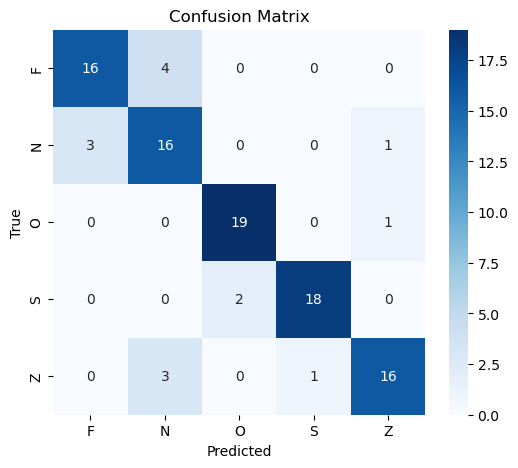

In [9]:
# Eğitim
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[callbacks, reduce_lr]
)

# Test metrikleri
class_names = ["F", "N", "O", "S", "Z"]  # kendi sınıflarını buraya yaz
evaluate_model(model, X_val, y_val, class_names)



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def plot_single_eeg(file_path, fs=256, max_freq=50):
    """
    Belirtilen tek bir EEG dosyası (.txt) için zaman ve frekans domeni grafiklerini çizer.
    Bu fonksiyon Jupyter ortamında çalışmak üzere tasarlanmıştır, bir GUI penceresi açmaz.

    Parametreler:
    - file_path (str): EEG verisini içeren .txt dosyasının yolu.
    - fs (int): Örnekleme frekansı (Hz). Varsayılan olarak 256'dır.
    - max_freq (int): PSD grafiğinde gösterilecek maksimum frekans. Varsayılan olarak 50'dir.
    """
    try:
        # Dosyadan veriyi oku
        signal = np.loadtxt(file_path)
        
        # Grafik figürünü ve alt grafiklerini oluştur
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # 1️⃣ Zaman domeni grafiği
        axes[0].plot(signal, color="b")
        axes[0].set_title("Ham EEG Sinyali")
        axes[0].set_xlabel("Zaman Noktası")
        axes[0].set_ylabel("Amplitüd")
        axes[0].grid(True)
        
        # 2️⃣ PSD grafiği
        # Güç Spektral Yoğunluğu (PSD) hesapla
        f, Pxx = welch(signal, fs=fs, nperseg=1024)
        axes[1].plot(f, Pxx, color="r")
        axes[1].set_xlim(0, max_freq)
        axes[1].set_title("Güç Spektral Yoğunluğu (PSD)")
        axes[1].set_xlabel("Frekans (Hz)")
        axes[1].set_ylabel("PSD")
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show() # Grafiği doğrudan Jupyter hücresinde göster
        
    except FileNotFoundError:
        print(f"Hata: Belirtilen dosya bulunamadı: {file_path}")
    except Exception as e:
        print(f"Dosya işlenirken bir hata oluştu: {e}")

# Fonksiyonu bir örnek dosya yolu ile nasıl kullanacağınız aşağıda gösterilmiştir.
# ÖNEMLİ: Lütfen aşağıdaki dosya yolunu kendi .txt dosyanızın yolu ile değiştirin.
# örnek_dosya_yolu = "C:/Users/Mehmet Ersolak/Desktop/proje/ornek_eeg_verisi.txt"
# plot_single_eeg(örnek_dosya_yolu)

In [13]:
# Kaydet
model.save("C:/Users/Mehmet Ersolak/Desktop/proje-ana-dizini/models/final_model.keras")

# Yükle
from tensorflow.keras.models import load_model
model = load_model("C:/Users/Mehmet Ersolak/Desktop/proje-ana-dizini/models/final_model.keras")

# Örnek tek dosya tahmini
x_new = preprocess_file("C:/Users/Mehmet Ersolak/Desktop/EEG_Epilepsi_Proje/BTK PROJE(EEG)/N/N025.txt")
x_new = np.expand_dims(x_new, (0,-1))  # (1, 4096, 1)

pred = model.predict(x_new)
print("Tahmin:", classes[np.argmax(pred)], pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Tahmin: F [[6.5038192e-01 3.4351644e-01 1.1339598e-05 5.9928154e-03 9.7556534e-05]]
